# Example 04. Flexible fiber with intrinsic curvature in shear flow

A first-look prototype reproducing **figure 8(b)** of Delmotte, Climent
& Plouraboué, *J. Comput. Phys.* **286**, 14–37 (2015): the buckling
of a permanently-deformed rigid-bond fiber in simple shear. The
intrinsic curvature `κ_eq` breaks the symmetry that would otherwise
yield the symmetric "S-shape" of fig 8(a); during the tumbling motion
the minimum radius of curvature collapses dramatically (`2R_min/L ≈
0.26` in the paper, against an equilibrium `2R_eq/L = 200`).

Body model: `softmobility.FlexibleFiber` with
`intrinsic_curvature = KAPPA_0` — the rigid-bond Gears model with the
linearised bending torque of Delmotte 2015 §2.4. The global
`KAPPA_0` at the top of cell 6 controls the rest-state curvature; the
paper uses `1/(100 L)`.

## Convention

- Lab frame: flow direction $\hat{\mathbf{e}}_x$, gradient direction
  $\hat{\mathbf{e}}_y$ (default of `sm.shear_flow`), vorticity
  direction $-\hat{\mathbf{e}}_z$.
- Shear flow $\mathbf{u}(\mathbf{r}) = \dot\gamma\,y\,\hat{\mathbf{e}}_x$,
  $\dot\gamma = 1$. Shear plane is $xy$.
- Bead radius $a = 1$, fluid viscosity $\mu_0 = 1$.
- Rigid bonds of length $2a$ (no extensibility, no gap).
- Chain length between end-bead centres $L = (N-1) \cdot 2a$.

## Dimensionless bending stiffness

$$A = \frac{K_b}{8\pi\,\mu_0\,\dot\gamma\,a^4}.$$

For $a=\mu_0=\dot\gamma=1$, $A = K_b/(8\pi)$, so the default
$K_b = 200$ gives $A \approx 7.96$ — soft enough that even a tiny
intrinsic curvature seeds dramatic buckling during the tumbling phase.

## Initial orientation

`FlexibleFiber(planar=True)` bends in the **body** $xz$-plane
(orientation DOFs are Rodrigues angles around body
$\hat{\mathbf e}_y$). To align that bending plane with the **lab**
$xy$ shear plane we use
$R_\text{init} = R_z(\alpha) \cdot R_x(\pi/2)$ with in-plane tilt
$\alpha = \mathtt{ALPHA\_TILT}$ (default 0 — fiber aligned with the
flow at $t = 0$).

## Linearization caveat

`FlexibleFiber` uses the small-$\Delta\theta$ linearised bending
torque (Delmotte 2015 eq. 32+34 to first order in joint angles). The
amplitude diagnostic in
[`linear_curvature_findings.md`](linear_curvature_findings.md) shows
the linear model stays faithful through $\max|\Delta\theta| \approx
1.0$ rad; the buckling regime explored here typically peaks below
that.

## DOF layout

`FlexibleFiber(planar=True)` has $N-1$ DOFs:

$$[\theta_1, \dots, \theta_{N-1}].$$

No extension DOFs — bonds are rigid by construction (touching-spheres
"Gears Model"). Sphere 0's tangent is structurally aligned with body
$\hat{\mathbf{e}}_x$, so it has no orientation DOF.

## Imports

In [46]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import softmobility as sm
from softmobility.classes import figstyle

jax.config.update("jax_enable_x64", True)
figstyle.apply()
np.set_printoptions(precision=4, linewidth=120, suppress=True, sign=" ")

FIGDIR = "figures"

## Helpers

Copied from `softmobility/examples/02_sinking_fiber.ipynb`: lab-frame
bead positions from `rollout` output, and the snapshot drawing helpers.


In [47]:
def lab_bead_positions(fiber, positions, orientations, dofs, design=None):
    """Return an array of shape (n_steps, n_beads, 3) with lab-frame bead positions."""
    if design is None:
        design = np.asarray(fiber.design_defaults)
    n_steps = int(positions.shape[0])
    n_beads = fiber.Nspheres
    t_dummy = np.array([0.0])
    out = np.zeros((n_steps, n_beads, 3))
    body_frame_positions = np.zeros((n_beads, 3))
    for step in range(n_steps):
        dof_step = np.asarray(dofs[step])
        for i in range(n_beads):
            body_frame_positions[i] = np.asarray(
                fiber.spheres[i].position(dof_step, design, t_dummy)
            )
        R = np.asarray(sm.rotation_matrix(orientations[step]))
        out[step] = np.asarray(positions[step]) + body_frame_positions @ R.T
    return out


def draw_shape(ax, beads_xy, *, color, fill, line_width=1.5,
               bead_radius=1.0, opacity=1.0):
    """Draw a fiber as a connecting line plus one filled circle per bead."""
    xs, ys = beads_xy[:, 0], beads_xy[:, 1]
    ax.plot(xs, ys, color=color, linewidth=line_width, alpha=opacity)
    for cx, cy in zip(xs, ys, strict=True):
        ax.add_patch(plt.Circle(
            (cx, cy), bead_radius,
            edgecolor=color, facecolor=fill, linewidth=1.0, alpha=opacity,
        ))


def stack_shape(snapshot_xy, row_index, y_step):
    """Centre an (n_beads, 2) snapshot at the origin then shift down by row_index*y_step."""
    centred = snapshot_xy - snapshot_xy.mean(axis=0)
    centred = centred.copy()
    centred[:, 1] -= row_index * y_step
    return centred


def matrix_to_rodrigues(R):
    """Convert a 3x3 rotation matrix to a Rodrigues vector (axis · angle)."""
    R = np.asarray(R)
    cos_theta = np.clip((np.trace(R) - 1) / 2, -1.0, 1.0)
    theta = float(np.arccos(cos_theta))
    sin_theta = np.sin(theta)
    if abs(sin_theta) < 1e-10:
        return np.zeros(3)
    axis_unnorm = np.array([
        R[2, 1] - R[1, 2],
        R[0, 2] - R[2, 0],
        R[1, 0] - R[0, 1],
    ])
    return theta * axis_unnorm / (2 * sin_theta)


def Rx(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])


def Ry(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]])


def Rz(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])

## 1. Parameters and body

Build the planar `FlexibleFiber` with intrinsic curvature `KAPPA_0`.
Edit any of the four globals below to retune the simulation.

In [ ]:
# ===== User-tunable globals =====
N = 15                   # number of beads
radius = 1.0                  # bead radius
SHEAR_RATE = 1.0
K_B = 5000.0             # bending modulus  (A = K_B / (8π) ≈ 200)
ALPHA_TILT = 0.0         # in-shear-plane initial tilt (rad)

L_chain = (N - 1) * 2.0 * radius
KAPPA_0 = 1.0 / (100.0 * L_chain)   # intrinsic curvature  (Delmotte fig 8b: 1/(100 L))
# =================================

print(f"N = {N},  a = {radius},  L_chain = {L_chain}")
print(f"K_b = {K_B},  A = K_b/(8π) = {K_B / (8 * np.pi):.4f}")
print(f"κ_0 = 1/(100·L) = {KAPPA_0:.5g}  (a⁻¹)")
print(f"per-bond rest Δθ = 2a·κ_0 = {2 * radius * KAPPA_0:.5g}  (rad)")

fiber = sm.FlexibleFiber(
    n_beads=N,
    radius=radius,
    bending_rigidity=K_B,
    mass=0.0,            # no gravity
    planar=True,         # bending restricted to body xz-plane
    intrinsic_curvature=KAPPA_0,
)
print(f"\nfiber.Nspheres = {fiber.Nspheres},  fiber.Ndof = {fiber.Ndof}")
print(f"dof_variables: {fiber.dof_variables}")
print(f"design_variables: {fiber.design_variables}")

# Orientation DOF count (all DOFs are orientation for FlexibleFiber).
N_ORIENT_DOFS = N - 1    # θ_1 … θ_{N-1}

N = 15,  a = 1.0,  L_chain = 28.0
K_b = 5000.0,  A = K_b/(8π) = 198.9437
κ_0 = 1/(100·L) = 0.00035714  (a⁻¹)
per-bond rest Δθ = 2a·κ_0 = 0.00071429  (rad)

fiber.Nspheres = 15,  fiber.Ndof = 14
dof_variables: ['theta_1', 'theta_2', 'theta_3', 'theta_4', 'theta_5', 'theta_6', 'theta_7', 'theta_8', 'theta_9', 'theta_10', 'theta_11', 'theta_12', 'theta_13', 'theta_14']
design_variables: ['radius', 'K_b', 'mass', 'kappa_0']


## 2. Bretherton parameter and Jeffery period

Build a rigid $N$-bead linear chain (same geometry as the
`FlexibleFiber` at zero DOFs, bonds of length $2a$) and extract its
Bretherton parameter $B$ from the strain-coupling tensor. The Jeffery
period for the equivalent ellipsoid is

$$T_J = \frac{2\pi}{\dot\gamma}\left(c + \frac{1}{c}\right), \quad
c = \sqrt{\frac{1+B}{1-B}}.$$

In [ ]:
# Rigid chain at the FlexibleFiber equilibrium geometry: bonds of length 2a.
bond_eq = 2.0 * radius
rigid_chain_yaml = "spheres:\n" + "".join(
    f"  - radius: {radius}\n    position: [{bond_eq * i}, 0, 0]\n" for i in range(N)
)
rigid_chain = sm.SoftBody(rigid_chain_yaml, verbose=False, allow_overlap=True)
B = float(rigid_chain.compute_rigid_tensors().C_E[-1, 1])
c_factor = np.sqrt((1 + B) / (1 - B))
T_J = 2 * np.pi * (c_factor + 1 / c_factor) / SHEAR_RATE
print(f"Bretherton B = {B:.4f}")
print(f"c = sqrt((1+B)/(1-B)) = {c_factor:.4f}")
print(f"Jeffery period T_J = {T_J:.4f}  (sphere limit 4π = {4 * np.pi:.4f})")

Bretherton B = 0.9850
c = sqrt((1+B)/(1-B)) = 11.5217
Jeffery period T_J = 72.9385  (sphere limit 4π = 12.5664)


## 3. Shear flow

We use the library's built-in `sm.shear_flow(shear_rate)` which is
$\mathbf{u}(\mathbf r) = \dot\gamma\,y\,\hat{\mathbf{e}}_x$ — the shear
plane is $xy$.


In [50]:
flow = sm.shear_flow(shear_rate=SHEAR_RATE)

# Sanity check at a few sample points
for r in [(0, 0, 0), (0, 1, 0), (5, 2, 0), (3, -1, 4)]:
    u = flow.velocity(jnp.asarray(r), 0.0)
    print(f"u({r}) = {np.asarray(u)}")

u((0, 0, 0)) = [ 0.  0.  0.]
u((0, 1, 0)) = [ 1.  0.  0.]
u((5, 2, 0)) = [ 2.  0.  0.]
u((3, -1, 4)) = [-1.  0.  0.]


## 4. Rollout — two Jeffery periods

We integrate over $2\,T_J$ to capture multiple tumble cycles. RK4 at
$\mathrm{d}t = 10^{-3}$ is well within the bending-mode stability
limit at this $K_b$.

The body's initial orientation is built from
$R_\text{init} = R_z(\alpha) \cdot R_x(\pi/2)$:

- $R_x(\pi/2)$ rotates the body so its bending plane (body $xz$)
  aligns with the lab shear plane (lab $xy$).
- $R_z(\alpha)$ applies the in-plane tilt $\alpha = \mathtt{ALPHA\_TILT}$
  from the flow direction.

`init_dofs` is set to zero — the fiber starts straight in body frame.
With `KAPPA_0 ≠ 0` the boundary torques will drive it toward the
curved rest state; for the tiny `1/(100 L)` curvature this transient
is essentially invisible compared to the shear-driven buckling.

In [51]:
dt = 1e-3
n_steps = int(np.ceil(T_J / dt))
print(f"dt = {dt:g},  n_steps = {n_steps}  (2·T_J ≈ {2 * T_J:.2f})")

R_init = Rz(ALPHA_TILT) @ Rx(np.pi / 2)
init_orientation = jnp.asarray(matrix_to_rodrigues(R_init))
print(f"R_init =\n{R_init}")
print(f"init_orientation (Rodrigues) = {np.asarray(init_orientation)}")
print(f"lab tangent  R_init·ê_x = {R_init @ np.array([1.0, 0.0, 0.0])}")

# FlexibleFiber registers a 'gravity' field input even when mass=0, so we
# wire a zero-gravity field to satisfy FlowBodyRollout's input validator.
rollout = sm.FlowBodyRollout(
    soft_body=fiber,
    flow=flow,
    input_map={"gravity": sm.gravity_field(g=0.0)},
)

positions, orientations, dofs = rollout.rollout(
    dt=dt,
    n_steps=n_steps,
    init_position=jnp.zeros(3),
    init_orientation=init_orientation,
    init_dofs=jnp.zeros(fiber.Ndof),
)
positions = np.asarray(positions)
orientations = np.asarray(orientations)
dofs = np.asarray(dofs)
print(f"trajectory shapes: positions={positions.shape}, "
      f"orientations={orientations.shape}, dofs={dofs.shape}")
print(f"any NaN? positions={np.isnan(positions).any()}, dofs={np.isnan(dofs).any()}")

dt = 0.001,  n_steps = 72939  (2·T_J ≈ 145.88)
R_init =
[[ 1.  0.  0.]
 [ 0.  0. -1.]
 [ 0.  1.  0.]]
init_orientation (Rodrigues) = [ 1.5708  0.      0.    ]
lab tangent  R_init·ê_x = [ 1.  0.  0.]
trajectory shapes: positions=(72939, 3), orientations=(72939, 3), dofs=(72939, 14)
any NaN? positions=False, dofs=False


## 5. Sanity checks

Convert to lab-frame bead positions and check planarity + peak joint
angles (the linearised bending torque is faithful through
$|\Delta\theta| \approx 1.0$ rad — see
[`linear_curvature_findings.md`](linear_curvature_findings.md)).

In [52]:
design = np.asarray(fiber.design_defaults)

# All DOFs are orientation angles for FlexibleFiber (no extension DOFs).
dofs_orient = dofs[:, :N_ORIENT_DOFS]
max_abs_theta = float(np.max(np.abs(dofs_orient)))
djoint = np.diff(dofs_orient, axis=1)
max_djoint = float(np.max(np.abs(djoint)))
print(f"max |θ|        (joint angle, rad) = {max_abs_theta:.4f}")
print(f"max |Δθ_pair|  (bond-pair, rad)   = {max_djoint:.4f}  "
      f"(linearised-bending validity bound ≈ 1.0)")

# Compute lab-frame bead positions on a strided trajectory (1000 frames is
# more than enough for plotting). lab_bead_positions has a Python loop
# over steps, so we stride first to keep it fast.
n_frames = 1000
stride = max(1, n_steps // n_frames)
frame_indices = np.arange(0, n_steps, stride)
lab_pos_strided = lab_bead_positions(
    fiber,
    positions[frame_indices],
    orientations[frame_indices],
    dofs[frame_indices],
    design=design,
)
print(f"\nstrided trajectory: stride={stride}, n_frames={len(frame_indices)}")
print(f"lab_pos_strided shape: {lab_pos_strided.shape}")

# Planarity: with bending plane aligned to lab xy, the fiber should
# stay at z ≈ 0 in lab.
max_abs_z_lab = float(np.max(np.abs(lab_pos_strided[..., 2])))
print(f"max |z| over (strided) lab beads = {max_abs_z_lab:.3e}  "
      f"(expect ~ machine ε)")
print(f"\ninitial bead positions in lab (x, y, z):\n{lab_pos_strided[0]}")
print(f"final bead positions in lab (x, y, z):\n{lab_pos_strided[-1]}")

max |θ|        (joint angle, rad) = 2.7013
max |Δθ_pair|  (bond-pair, rad)   = 0.4086  (linearised-bending validity bound ≈ 1.0)

strided trajectory: stride=72, n_frames=1014
lab_pos_strided shape: (1014, 15, 3)
max |z| over (strided) lab beads = 1.653e-12  (expect ~ machine ε)

initial bead positions in lab (x, y, z):
[[ 0.      0.0001  0.    ]
 [ 2.     -0.      0.    ]
 [ 4.      0.      0.    ]
 [ 6.     -0.      0.    ]
 [ 8.     -0.      0.    ]
 [10.     -0.      0.    ]
 [12.     -0.      0.    ]
 [14.     -0.      0.    ]
 [16.     -0.      0.    ]
 [18.     -0.      0.    ]
 [20.     -0.      0.    ]
 [22.     -0.      0.    ]
 [24.     -0.      0.    ]
 [26.     -0.      0.    ]
 [28.      0.      0.    ]]
final bead positions in lab (x, y, z):
[[ 96.1792  -4.2665  -0.    ]
 [ 98.1618  -4.5302  -0.    ]
 [100.1578  -4.404   -0.    ]
 [102.1104  -3.9712  -0.    ]
 [103.9986  -3.3117  -0.    ]
 [105.8205  -2.4869  -0.    ]
 [107.5811  -1.5379  -0.    ]
 [109.2847  -0.4903  -0.

## 5b. Time series of $\theta_\text{tan}$ and $\kappa_\text{max}$

Two side-by-side panels — the natural diagnostics for the Jeffery
tumble at this $A$. The lab-frame fiber tangent angle is

$$\theta_\text{tan}(t) = \arctan_2\!\bigl(\hat{\mathbf t}_y,\;\hat{\mathbf t}_x\bigr),
\quad \hat{\mathbf t}(t) = R(\mathbf o(t)) \cdot \hat{\mathbf e}_x^\text{body},$$

unwrapped to track multiple revolutions. The peak chain curvature is

$$\kappa_\text{max}(t) = \max_i \, |\Delta\theta_i(t)| \,/\, (2a),$$

where $\Delta\theta_i = \theta_i - \theta_{i-1}$. **Snapshot times**
are defined in this cell (`SNAP_FRACTIONS`) and reused by cell 18; the
red `o` markers on each panel mark them.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


PosixPath('figures/fig_proto_fiber_shear_timeseries.pdf')

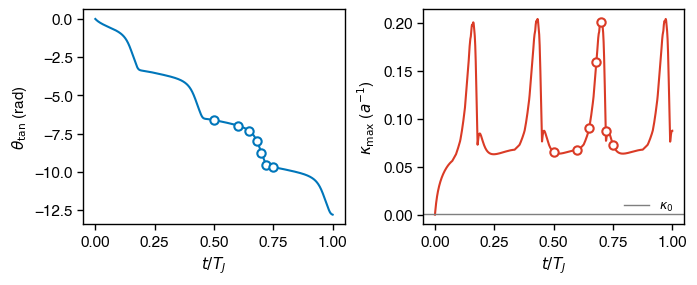

In [ ]:
t_strided = frame_indices * dt
ori_strided = orientations[frame_indices]
dofs_strided = dofs[frame_indices]

orient_strided = dofs_strided[:, :N_ORIENT_DOFS]
curvature = np.diff(orient_strided, axis=1) / L_chain
curvature_max = np.max(np.abs(curvature), axis=1)

# Lab-frame fiber tangent at each strided time, then its angle in xy
# (unwrapped so the tumbling motion shows as a monotonic descent).
tangents = np.array([
    np.asarray(sm.rotation_matrix(ori)) @ np.array([1.0, 0.0, 0.0])
    for ori in ori_strided
])
theta_tan = np.unwrap(np.arctan2(tangents[:, 1], tangents[:, 0]))

# ===== USER: snapshot fractions of T_J (reused in cell 18 for the shape stack) =====
SNAP_FRACTIONS = [0.50, 0.60, 0.65, 0.68, 0.70, 0.72,0.75, ]
# ====================================================================================
snap_times = np.array([f * T_J for f in SNAP_FRACTIONS])
snap_frames = np.array([int(np.argmin(np.abs(t_strided - t))) for t in snap_times])
actual_times = t_strided[snap_frames]

fig_ts, axes_ts = figstyle.subplots(size="full", aspect=2.5, ncols=2, nrows=1)

axes_ts[0].plot(t_strided / T_J, theta_tan,
                color=figstyle.COLORS["blue"], linewidth=1.5)
axes_ts[0].plot(actual_times / T_J, theta_tan[snap_frames],
                marker="o", linestyle="", markersize=6,
                markeredgecolor=figstyle.COLORS["blue"],
                markerfacecolor="white", markeredgewidth=1.5)
# axes_ts[0].axhline(ALPHA_TILT, color=figstyle.COLORS["grey"],
#                    linestyle="--", linewidth=1.0)
axes_ts[0].set_xlabel(r"$t / T_J$")
axes_ts[0].set_ylabel(r"$\theta_0$ (rad)")

axes_ts[1].plot(t_strided / T_J, curvature_max,
                color=figstyle.COLORS["red"], linewidth=1.5)
axes_ts[1].plot(actual_times / T_J, curvature_max[snap_frames],
                marker="o", linestyle="", markersize=6,
                markeredgecolor=figstyle.COLORS["red"],
                markerfacecolor="white", markeredgewidth=1.5)
axes_ts[1].axhline(KAPPA_0, color=figstyle.COLORS["grey"],
                   linestyle="-", linewidth=1.0,
                   label=r"$\kappa_0$")
axes_ts[1].set_xlabel(r"$t / T_J$")
axes_ts[1].set_ylabel(r"$\kappa_\mathrm{max}$ ($L^{-1}$)")
axes_ts[1].legend(loc="best", frameon=False, fontsize=9)

figstyle.save(fig_ts, "fig_proto_fiber_shear_timeseries", figdir=FIGDIR)

## 6. Shape snapshots — horizontal stack

Each snapshot is COM-centred and placed left-to-right in time order
(earliest at the left). Snapshot times come from `SNAP_FRACTIONS` in
the cell above — edit there to retune which moments are shown; the
red `o` markers on the time-series figure follow the same list.

PosixPath('figures/fig_proto_fiber_shear_shapes.pdf')

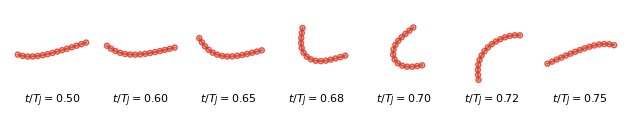

In [ ]:
# Horizontal stack: each snapshot is COM-centred and shifted right by
# `x_step`. snap_frames / actual_times come from the time-series cell.
x_step = 1.25 * L_chain
y_half = 0.6 * L_chain

fig, ax = figstyle.figure(size="full", aspect=3.0)

for i, frame in enumerate(snap_frames):
    snap_xy = lab_pos_strided[frame][:, [0, 1]]
    centred = snap_xy - snap_xy.mean(axis=0)
    centred[:, 0] += i * x_step
    draw_shape(
        ax, centred,
        color=figstyle.COLORS["red"],
        fill=figstyle.COLORS["red_25"],
        bead_radius=radius,
        opacity=0.85,
    )
    ax.text(
        i * x_step, -y_half * 0.95,
        rf"$t/T_J = {actual_times[i] / T_J:.2f}$",
        fontsize=8, ha="center", va="top",
        color=figstyle.COLORS["black"],
    )

ax.set_xlim(-0.6 * L_chain, (len(snap_frames) - 1) * x_step + 0.6 * L_chain)
ax.set_ylim(-y_half, y_half)
ax.set_aspect("equal")
ax.set_axis_off()

figstyle.save(fig, "fig_proto_fiber_shear_shapes", figdir=FIGDIR)

## Summary

This prototype simulates a rigid-bond chain of $N=8$ touching beads in
simple shear, qualitatively reproducing **figure 8(b)** of Delmotte,
Climent & Plouraboué 2015 — the buckling of a fiber with small
permanent curvature $\kappa_0$. Observations from the run above:

- Bretherton $B$ and the resulting Jeffery period $T_J$ set the time
  normalisation; both are printed by cell 8.
- The intrinsic curvature `KAPPA_0` $= 1/(100\,L) \approx 7\times 10^{-4}$
  is too small to deflect the fiber appreciably at rest (per-bond
  $\Delta\theta_\text{eq} \approx 0.001$ rad), but it is enough to seed
  the buckling instability under shear. The grey dashed line in the
  curvature panel marks $\kappa_0$ for reference.
- The shape-stack figure (`fig_proto_fiber_shear_shapes.pdf`) lays the
  selected snapshots out left-to-right in time order; the red `o`
  markers on the time-series figure mark the same instants.

Knobs at the top of cell 6: `N`, `K_B`, `KAPPA_0`, `ALPHA_TILT`. Knob
in the time-series cell: `SNAP_FRACTIONS` (reused by the shape
figure).

Next steps (out of scope for this prototype):

- Sweep $A$ to map the rigid-rod ↔ buckling transition.
- Sweep $\kappa_0$ to recover the Forgacs–Mason / Salinas–Pittman
  $\min(2R_\text{min}/L)$ vs $BR$ curve at fixed $A$.
- Compare with the geometrically-nonlinear elastica BVP (see
  `linear_curvature_validation.py` for the BVP solver pattern).